In [1]:
import sys
print(sys.executable)

c:\Users\Chimdinma\anaconda3\python.exe


In [1]:
import sys
print(sys.executable)


c:\Users\Chimdinma\Documents\tECHY JAUNT\final project\generated_data\Farm2Market-GitHub\Tomatoes-Distribution-App\.venv\Scripts\python.exe


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
print("Notebook working directory:")
print(Path.cwd())

Notebook working directory:
c:\Users\Chimdinma\Documents\tECHY JAUNT\final project\generated_data\Farm2Market-GitHub\Tomatoes-Distribution-App\data-science\notebooks


In [86]:
possible_paths = [
    Path("data-science/data/tomato_supply_chain_master_cleaned.csv"),
    Path("../data/tomato_supply_chain_master_cleaned.csv"),
]

data_path = next(
    (path for path in possible_paths if path.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Confirm that the CSV is inside "
        "data-science/data."
    )


df = pd.read_csv(
    data_path,
    keep_default_na=False,
    na_values=[""]
)

print("Dataset reloaded successfully.")
print("Dataset shape:", df.shape)

Dataset reloaded successfully.
Dataset shape: (10000, 45)


In [87]:
df.shape

(10000, 45)

In [88]:
categorical_features = [
    "originState",
    "destinationCity",
    "season",
    "packagingType",
    "transportMode",
    "coldStorageAvailable",
    "storageType",
    "ripenessLevel",
    "initialDamageLevel"
]

numerical_features = [
    "routeDistanceKm",
    "quantitySentCrates",
    "hoursSinceHarvestAtDispatch"
]

model_features = categorical_features + numerical_features
target = "spoilageStatus"

required_columns = model_features + [target]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

print("Number of predictors:", len(model_features))
print("Missing columns:", missing_columns)

Number of predictors: 12
Missing columns: []


In [89]:
model_df = df[required_columns].copy()

print("Modelling dataset shape:", model_df.shape)

Modelling dataset shape: (10000, 13)


In [90]:
model_df = df[required_columns].copy()

print("Modelling dataset shape:", model_df.shape)

model_df.head()

Modelling dataset shape: (10000, 13)


,originState,destinationCity,season,packagingType,transportMode,coldStorageAvailable,storageType,ripenessLevel,initialDamageLevel,routeDistanceKm,quantitySentCrates,hoursSinceHarvestAtDispatch,spoilageStatus
0,Kaduna,Ibadan,Dry Season,Plastic Crate,Covered Truck,Yes,Shaded Storage,Overripe,None,790.7,85,25.0,0
1,Kano,Port Harcourt,Dry Season,Sack,Traditional Open Truck,Yes,Cold Storage,Unripe,Low,1302.9,266,11.0,0
2,Kaduna,Port Harcourt,Dry Season,Plastic Crate,Traditional Open Truck,No,No Storage,Ripe,None,1044.5,229,24.0,0
3,Gombe,Ibadan,Dry Season,Raffia Basket,Traditional Open Truck,No,No Storage,Ripe,Moderate,1060.1,117,27.3,1
4,Plateau,Port Harcourt,Dry Season,Sack,Traditional Open Truck,No,Open Storage,Unripe,Moderate,742.3,78,7.4,1


In [91]:
model_df.dtypes

originState                        str
destinationCity                    str
season                             str
packagingType                      str
transportMode                      str
coldStorageAvailable               str
storageType                        str
ripenessLevel                      str
initialDamageLevel                 str
routeDistanceKm                float64
quantitySentCrates               int64
hoursSinceHarvestAtDispatch    float64
spoilageStatus                   int64
dtype: object

In [92]:
for column in categorical_features:
    unique_values = (
        model_df[column]
        .dropna()
        .astype(str)
        .sort_values()
        .unique()
        .tolist()
    )

    print(f"\n{column}")
    print(unique_values)
    print("Missing values:", model_df[column].isna().sum())


originState
['Gombe', 'Kaduna', 'Kano', 'Plateau']
Missing values: 0

destinationCity
['Ibadan', 'Lagos', 'Onitsha', 'Port Harcourt']
Missing values: 0

season
['Dry Season', 'Rainy Season']
Missing values: 0

packagingType
['Plastic Crate', 'Raffia Basket', 'Sack', 'Wooden Crate']
Missing values: 0

transportMode
['Covered Truck', 'Refrigerated Reefer Van', 'Traditional Open Truck']
Missing values: 0

coldStorageAvailable
['No', 'Yes']
Missing values: 0

storageType
['Cold Storage', 'No Storage', 'Open Storage', 'Shaded Storage']
Missing values: 0

ripenessLevel
['Overripe', 'Ripe', 'Semi-ripe', 'Unripe']
Missing values: 0

initialDamageLevel
['Low', 'Moderate', 'None', 'Severe']
Missing values: 0


In [93]:
model_df["destinationCity"].value_counts(dropna=False)

destinationCity
Onitsha          2566
Ibadan           2544
Lagos            2479
Port Harcourt    2411
Name: count, dtype: int64

In [94]:
model_df[numerical_features].describe().round(2)

,routeDistanceKm,quantitySentCrates,hoursSinceHarvestAtDispatch
count,10000.00,10000.00,10000.00
mean,948.13,175.94,18.85
std,186.00,72.75,9.86
min,457.00,50.00,2.00
25%,812.02,113.00,10.30
50%,948.45,177.00,18.80
75%,1079.70,239.00,27.40
max,1370.20,300.00,36.00


In [95]:
for column in numerical_features:
    print(
        column,
        "| Minimum:", model_df[column].min(),
        "| Maximum:", model_df[column].max()
    )

routeDistanceKm | Minimum: 457.0 | Maximum: 1370.2
quantitySentCrates | Minimum: 50 | Maximum: 300
hoursSinceHarvestAtDispatch | Minimum: 2.0 | Maximum: 36.0


In [96]:
quality_summary = pd.DataFrame({
    "dataType": model_df.dtypes.astype(str),
    "missingValues": model_df.isna().sum(),
    "uniqueValues": model_df.nunique()
})

quality_summary

,dataType,missingValues,uniqueValues
originState,str,0,4
destinationCity,str,0,4
season,str,0,2
packagingType,str,0,4
transportMode,str,0,3
coldStorageAvailable,str,0,2
storageType,str,0,4
ripenessLevel,str,0,4
initialDamageLevel,str,0,4
routeDistanceKm,float64,0,5259


In [97]:
print("Total missing values:", model_df.isna().sum().sum())
print("Duplicate modelling rows:", model_df.duplicated().sum())
print("Target values:", sorted(model_df[target].unique()))

Total missing values: 0
Duplicate modelling rows: 0
Target values: [np.int64(0), np.int64(1)]


In [98]:
target_distribution = pd.DataFrame({
    "count": model_df[target].value_counts().sort_index(),
    "percentage": (
        model_df[target]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

target_distribution

,count,percentage
spoilageStatus,,
0,6779,67.79
1,3221,32.21


### Target distribution

Approximately 68% of the shipments are classified as not spoiled, while 32% are classified as spoiled. This represents moderate class imbalance.

Accuracy will not be used as the only evaluation metric. Recall for the spoiled class is particularly important because a false negative represents a high-risk shipment that the model incorrectly identifies as safe. Precision, F1-score, ROC-AUC and the confusion matrix will also be considered.

In [99]:
X = model_df[model_features].copy()
y = model_df[target].copy()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (10000, 12)
Target shape: (10000,)


In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Modelling tools imported successfully.")

Modelling tools imported successfully.


In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 12)
X_test: (2000, 12)
y_train: (8000,)
y_test: (2000,)


In [102]:
split_distribution = pd.DataFrame({
    "trainingPercentage": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
    "testingPercentage": (
        y_test.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

split_distribution

,trainingPercentage,testingPercentage
spoilageStatus,,
0,67.79,67.8
1,32.21,32.2


In [103]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_features
        ),
        (
            "numerical",
            numerical_transformer,
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [104]:
X_train_transformed = preprocessor.fit_transform(X_train)

print("Original training shape:", X_train.shape)
print("Transformed training shape:", X_train_transformed.shape)

Original training shape: (8000, 12)
Transformed training shape: (8000, 34)


In [105]:
transformed_feature_names = (
    preprocessor
    .get_feature_names_out()
    .tolist()
)

print("Number of transformed features:", len(transformed_feature_names))
print("\nFirst 20 transformed features:")

transformed_feature_names[:20]

Number of transformed features: 34

First 20 transformed features:


['categorical__originState_Gombe',
 'categorical__originState_Kaduna',
 'categorical__originState_Kano',
 'categorical__originState_Plateau',
 'categorical__destinationCity_Ibadan',
 'categorical__destinationCity_Lagos',
 'categorical__destinationCity_Onitsha',
 'categorical__destinationCity_Port Harcourt',
 'categorical__season_Dry Season',
 'categorical__season_Rainy Season',
 'categorical__packagingType_Plastic Crate',
 'categorical__packagingType_Raffia Basket',
 'categorical__packagingType_Sack',
 'categorical__packagingType_Wooden Crate',
 'categorical__transportMode_Covered Truck',
 'categorical__transportMode_Refrigerated Reefer Van',
 'categorical__transportMode_Traditional Open Truck',
 'categorical__coldStorageAvailable_No',
 'categorical__coldStorageAvailable_Yes',
 'categorical__storageType_Cold Storage']

In [106]:
# Build one complete pipeline containing:
# 1. The preprocessing steps created earlier
# 2. The Logistic Regression classification model
#
# Keeping preprocessing and modelling in one pipeline ensures that
# the same transformations used during training will also be used
# when FastAPI receives new shipment data.

logistic_pipeline = Pipeline(
    steps=[
        # Convert categorical variables to numbers and scale numerical variables
        ("preprocessor", preprocessor),

        # Train the Logistic Regression classifier
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,

                # Give additional importance to the less frequent spoiled class
                class_weight="balanced",

                # Ensure reproducible results
                random_state=42
            )
        )
    ]
)

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float

In [107]:
# Train the complete pipeline using the training dataset.
#
# During this process:
# - categorical values are one-hot encoded;
# - numerical values are scaled;
# - the Logistic Regression model learns patterns associated with spoilage.

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression training completed successfully.")

Logistic Regression training completed successfully.


In [108]:
# Predict the final class for each shipment in the test dataset.
#
# The result will be:
# 0 = predicted not spoiled
# 1 = predicted spoiled

logistic_predictions = logistic_pipeline.predict(X_test)


# Predict the probability that each shipment belongs to class 1.
#
# predict_proba returns probabilities for both classes:
# column 0 = probability of not spoiled
# column 1 = probability of spoiled
#
# We select column 1 because spoilage is the outcome of interest.

logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]


print("Number of class predictions:", len(logistic_predictions))
print("Number of probability predictions:", len(logistic_probabilities))

Number of class predictions: 2000
Number of probability predictions: 2000


In [109]:
# Create a comparison table showing:
# - the real spoilage result;
# - the model's predicted result;
# - the predicted probability of spoilage.

logistic_results = pd.DataFrame({
    "actualStatus": y_test.reset_index(drop=True),
    "predictedStatus": logistic_predictions,
    "spoilageProbability": logistic_probabilities
})


# Round the probability for easier reading
logistic_results["spoilageProbability"] = (
    logistic_results["spoilageProbability"].round(4)
)


logistic_results.head(10)

,actualStatus,predictedStatus,spoilageProbability
0,0,1,0.5920
1,0,1,0.7892
2,1,1,0.7456
3,1,0,0.3185
4,1,1,0.5187
5,1,1,0.6248
6,0,0,0.2306
7,0,1,0.7503
8,0,0,0.2937
9,0,0,0.2583


In [110]:
# Calculate the main classification metrics.
#
# We focus particularly on class 1 because it represents spoiled shipments.

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    pos_label=1
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    pos_label=1
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    pos_label=1
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)


# Store the results in a dictionary for later comparison
logistic_metrics = {
    "model": "Logistic Regression",
    "accuracy": logistic_accuracy,
    "precisionSpoiled": logistic_precision,
    "recallSpoiled": logistic_recall,
    "f1Spoiled": logistic_f1,
    "rocAuc": logistic_roc_auc
}


# Display the results as a clean table
logistic_metrics_df = pd.DataFrame(
    [logistic_metrics]
).round(3)

logistic_metrics_df

,model,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,rocAuc
0,Logistic Regression,0.686,0.508,0.711,0.593,0.769


In [111]:
# Display performance separately for:
# - class 0: Not Spoiled
# - class 1: Spoiled

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "Not Spoiled",
            "Spoiled"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Spoiled       0.83      0.67      0.74      1356
     Spoiled       0.51      0.71      0.59       644

    accuracy                           0.69      2000
   macro avg       0.67      0.69      0.67      2000
weighted avg       0.73      0.69      0.70      2000



In [112]:
# Create the confusion matrix.
#
# The arrangement is:
#
# [[True Negatives,  False Positives],
#  [False Negatives, True Positives]]

logistic_confusion_matrix = confusion_matrix(
    y_test,
    logistic_predictions
)

logistic_confusion_matrix

array([[913, 443],
       [186, 458]])

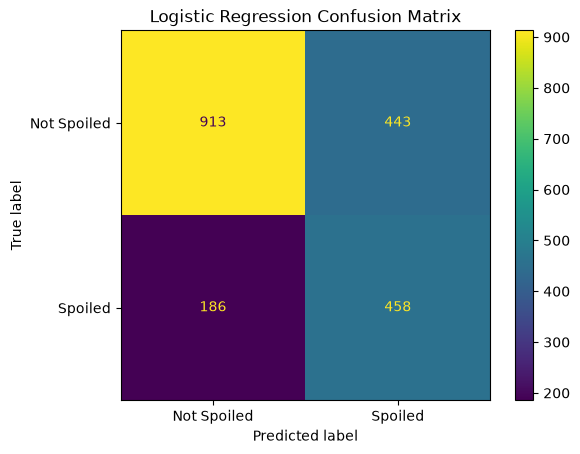

In [113]:
# Import the visual confusion matrix tool

from sklearn.metrics import ConfusionMatrixDisplay


# Display the confusion matrix with readable class labels

ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=[
        "Not Spoiled",
        "Spoiled"
    ]
).plot()


# Add a descriptive title
plt.title("Logistic Regression Confusion Matrix")


# Display the chart
plt.show()

In [114]:
# Generate predictions for the training dataset

logistic_train_predictions = logistic_pipeline.predict(X_train)


# Calculate training and testing accuracy

logistic_train_accuracy = accuracy_score(
    y_train,
    logistic_train_predictions
)

logistic_test_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)


print(
    "Training accuracy:",
    round(logistic_train_accuracy, 3)
)

print(
    "Testing accuracy:",
    round(logistic_test_accuracy, 3)
)

Training accuracy: 0.695
Testing accuracy: 0.685


## Logistic Regression Baseline Results

Logistic Regression was trained as the baseline classification model. The model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC and the confusion matrix.

Particular attention was given to recall for the spoiled class because a false-negative prediction would classify a genuinely high-risk shipment as safe. The Logistic Regression results will be compared with a Random Forest model before selecting the final production model.

In [115]:
logistic_metrics_df

,model,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,rocAuc
0,Logistic Regression,0.686,0.508,0.711,0.593,0.769


In [116]:
logistic_confusion_matrix

array([[913, 443],
       [186, 458]])

In [117]:
print(
    "Training accuracy:",
    round(logistic_train_accuracy, 3)
)

print(
    "Testing accuracy:",
    round(logistic_test_accuracy, 3)
)

Training accuracy: 0.695
Testing accuracy: 0.685


In [118]:
# Import clone so each model receives its own independent
# copy of the preprocessing pipeline.

from sklearn.base import clone

In [119]:
# Build a complete Random Forest pipeline.
#
# The pipeline first preprocesses the original farmer-friendly
# inputs, then passes the transformed values to the classifier.

random_forest_pipeline = Pipeline(
    steps=[
        # Use a fresh copy of the preprocessing steps
        ("preprocessor", clone(preprocessor)),

        # Create the Random Forest classification model
        (
            "classifier",
            RandomForestClassifier(
                # Build 300 decision trees
                n_estimators=300,

                # Allow trees to grow until the stopping rules are reached
                max_depth=None,

                # Require at least five records before splitting a node
                min_samples_split=5,

                # Require at least two records in each final leaf
                min_samples_leaf=2,

                # Give more importance to the less frequent spoiled class
                class_weight="balanced",

                # Use all available processor cores
                n_jobs=-1,

                # Ensure reproducible results
                random_state=42
            )
        )
    ]
)

random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float

In [120]:
# Train both the preprocessing steps and the Random Forest
# classifier using the training dataset.

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


In [121]:
# Predict the final spoilage class for each test shipment.
#
# 0 = Not Spoiled
# 1 = Spoiled

random_forest_predictions = (
    random_forest_pipeline.predict(X_test)
)


# Calculate the probability that each shipment belongs
# to the spoiled class.

random_forest_probabilities = (
    random_forest_pipeline.predict_proba(X_test)[:, 1]
)


print(
    "Number of class predictions:",
    len(random_forest_predictions)
)

print(
    "Number of probability predictions:",
    len(random_forest_probabilities)
)

Number of class predictions: 2000
Number of probability predictions: 2000


In [122]:
# Create a table comparing:
# - the actual result;
# - the Random Forest prediction;
# - the predicted spoilage probability.

random_forest_results = pd.DataFrame({
    "actualStatus": y_test.reset_index(drop=True),
    "predictedStatus": random_forest_predictions,
    "spoilageProbability": random_forest_probabilities
})


# Round the probability for easier interpretation

random_forest_results["spoilageProbability"] = (
    random_forest_results["spoilageProbability"]
    .round(4)
)


random_forest_results.head(10)

,actualStatus,predictedStatus,spoilageProbability
0,0,0,0.4870
1,0,1,0.6575
2,1,1,0.7001
3,1,0,0.2271
4,1,0,0.3996
5,1,1,0.5400
6,0,0,0.2543
7,0,1,0.6105
8,0,0,0.3051
9,0,0,0.2713


In [123]:
# Calculate the main model evaluation metrics.

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions,
    pos_label=1
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions,
    pos_label=1
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions,
    pos_label=1
)

random_forest_roc_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)


# Store the metrics for comparison with Logistic Regression

random_forest_metrics = {
    "model": "Random Forest",
    "accuracy": random_forest_accuracy,
    "precisionSpoiled": random_forest_precision,
    "recallSpoiled": random_forest_recall,
    "f1Spoiled": random_forest_f1,
    "rocAuc": random_forest_roc_auc
}


# Display the results in a table

random_forest_metrics_df = pd.DataFrame(
    [random_forest_metrics]
).round(3)

random_forest_metrics_df

,model,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,rocAuc
0,Random Forest,0.696,0.525,0.579,0.551,0.747


In [124]:
# Display precision, recall and F1-score separately
# for not-spoiled and spoiled shipments.

print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=[
            "Not Spoiled",
            "Spoiled"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Not Spoiled       0.79      0.75      0.77      1356
     Spoiled       0.53      0.58      0.55       644

    accuracy                           0.70      2000
   macro avg       0.66      0.67      0.66      2000
weighted avg       0.70      0.70      0.70      2000



In [125]:
# Create the Random Forest confusion matrix.
#
# Arrangement:
#
# [[True Negatives,  False Positives],
#  [False Negatives, True Positives]]

random_forest_confusion_matrix = confusion_matrix(
    y_test,
    random_forest_predictions
)

random_forest_confusion_matrix

array([[1019,  337],
       [ 271,  373]])

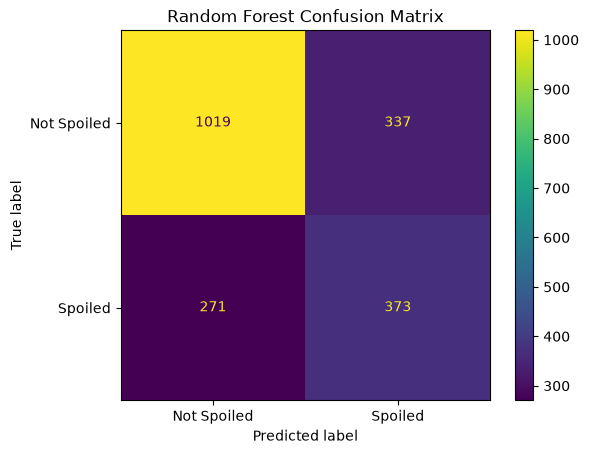

In [126]:
# Display the Random Forest confusion matrix
# with readable labels.

ConfusionMatrixDisplay(
    confusion_matrix=random_forest_confusion_matrix,
    display_labels=[
        "Not Spoiled",
        "Spoiled"
    ]
).plot()


# Add a descriptive title

plt.title("Random Forest Confusion Matrix")


# Display the chart

plt.show()

In [127]:
# Generate predictions for the training dataset.

random_forest_train_predictions = (
    random_forest_pipeline.predict(X_train)
)


# Calculate training and testing accuracy.

random_forest_train_accuracy = accuracy_score(
    y_train,
    random_forest_train_predictions
)

random_forest_test_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)


print(
    "Training accuracy:",
    round(random_forest_train_accuracy, 3)
)

print(
    "Testing accuracy:",
    round(random_forest_test_accuracy, 3)
)

Training accuracy: 0.945
Testing accuracy: 0.696


In [128]:
# Combine the Logistic Regression and Random Forest
# metrics into one comparison table.

model_comparison = pd.DataFrame([
    logistic_metrics,
    random_forest_metrics
])


# Use the model name as the table index
# and round the numerical results.

model_comparison = (
    model_comparison
    .set_index("model")
    .round(3)
)

model_comparison

,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,rocAuc
model,,,,,
Logistic Regression,0.686,0.508,0.711,0.593,0.769
Random Forest,0.696,0.525,0.579,0.551,0.747


In [129]:
# Extract the number of spoiled shipments that each
# model incorrectly classified as not spoiled.

logistic_false_negatives = (
    logistic_confusion_matrix[1, 0]
)

random_forest_false_negatives = (
    random_forest_confusion_matrix[1, 0]
)


false_negative_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "falseNegatives": [
        logistic_false_negatives,
        random_forest_false_negatives
    ]
})


false_negative_comparison

,model,falseNegatives
0,Logistic Regression,186
1,Random Forest,271


In [130]:
# Include training accuracy, testing accuracy and
# false negatives to help identify overfitting.

detailed_model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "trainingAccuracy": [
        logistic_train_accuracy,
        random_forest_train_accuracy
    ],
    "testingAccuracy": [
        logistic_test_accuracy,
        random_forest_test_accuracy
    ],
    "precisionSpoiled": [
        logistic_precision,
        random_forest_precision
    ],
    "recallSpoiled": [
        logistic_recall,
        random_forest_recall
    ],
    "f1Spoiled": [
        logistic_f1,
        random_forest_f1
    ],
    "rocAuc": [
        logistic_roc_auc,
        random_forest_roc_auc
    ],
    "falseNegatives": [
        logistic_false_negatives,
        random_forest_false_negatives
    ]
})


detailed_model_comparison.round(3)

,model,trainingAccuracy,testingAccuracy,precisionSpoiled,recallSpoiled,f1Spoiled,rocAuc,falseNegatives
0,Logistic Regression,0.695,0.686,0.508,0.711,0.593,0.769,186
1,Random Forest,0.945,0.696,0.525,0.579,0.551,0.747,271


## Random Forest and Baseline Comparison

The Random Forest model was evaluated against the Logistic Regression baseline using the same training and testing records.

Model selection will not be based on accuracy alone. The preferred model should demonstrate strong recall and F1-score for spoiled shipments, a high ROC-AUC score and a relatively low number of false negatives. Training and testing performance will also be compared to identify possible overfitting.

Because the dataset is synthetic, these results demonstrate prototype performance only and must not be interpreted as validated performance on real Nigerian tomato shipments.

In [131]:
model_comparison

,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,rocAuc
model,,,,,
Logistic Regression,0.686,0.508,0.711,0.593,0.769
Random Forest,0.696,0.525,0.579,0.551,0.747


## Initial Model Selection

Logistic Regression was selected as the provisional model because it achieved stronger recall, F1-score and ROC-AUC than Random Forest.

Although Random Forest recorded slightly higher accuracy and precision, it identified a substantially smaller proportion of genuinely spoiled shipments. Logistic Regression achieved a recall of 70.5%, compared with 58.9% for Random Forest.

For this application, false-negative predictions are particularly costly because they classify a genuinely high-risk shipment as safe. The Logistic Regression probability threshold will therefore be examined before the final model is saved.

In [132]:
# Import tools for stratified cross-validation and
# out-of-fold probability predictions.

from sklearn.model_selection import StratifiedKFold, cross_val_predict


# Create five stratified folds.
# Stratification preserves the class distribution in each fold.

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Generate probabilities for each training record using a model
# that was not trained on that particular record.
#
# This allows us to examine prediction thresholds without using
# the test dataset during threshold selection.

training_probabilities = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cross_validation,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


print(
    "Number of out-of-fold probabilities:",
    len(training_probabilities)
)

Number of out-of-fold probabilities: 8000


In [133]:
# Create decision thresholds from 0.30 to 0.70.
#
# A lower threshold usually increases recall but reduces precision.
# A higher threshold usually increases precision but reduces recall.

thresholds = np.arange(0.30, 0.71, 0.01)

threshold_results = []


# Test every threshold using the out-of-fold training probabilities.

for threshold in thresholds:

    # Convert probabilities into final class predictions.
    threshold_predictions = (
        training_probabilities >= threshold
    ).astype(int)

    # Generate the confusion matrix values.
    tn, fp, fn, tp = confusion_matrix(
        y_train,
        threshold_predictions
    ).ravel()

    # Store the evaluation results.
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_train,
            threshold_predictions
        ),
        "precisionSpoiled": precision_score(
            y_train,
            threshold_predictions,
            zero_division=0
        ),
        "recallSpoiled": recall_score(
            y_train,
            threshold_predictions
        ),
        "f1Spoiled": f1_score(
            y_train,
            threshold_predictions
        ),
        "falsePositives": fp,
        "falseNegatives": fn
    })


# Convert the results into a DataFrame.

threshold_results_df = pd.DataFrame(
    threshold_results
)


threshold_results_df.head()

,threshold,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,falsePositives,falseNegatives
0,0.30,0.564625,0.419395,0.914629,0.575088,3263,220
1,0.31,0.573875,0.424528,0.908033,0.578563,3172,237
2,0.32,0.581625,0.428809,0.899884,0.580839,3089,258
3,0.33,0.589750,0.433603,0.893287,0.583819,3007,275
4,0.34,0.596250,0.437416,0.885526,0.585579,2935,295


In [134]:
# Display thresholds between 0.35 and 0.55.
#
# This range is usually the most useful for examining the
# trade-off between recall and precision.

threshold_results_df[
    threshold_results_df["threshold"].between(
        0.35,
        0.55
    )
].round(3)

,threshold,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,falsePositives,falseNegatives
5,0.35,0.603,0.441,0.875,0.587,2853,323
6,0.36,0.609,0.445,0.864,0.587,2781,350
7,0.37,0.616,0.450,0.856,0.590,2701,371
8,0.38,0.623,0.455,0.847,0.592,2619,394
9,0.39,0.628,0.457,0.835,0.591,2552,425
10,0.40,0.635,0.462,0.824,0.592,2470,453
11,0.41,0.640,0.467,0.815,0.593,2398,478
12,0.42,0.647,0.472,0.804,0.595,2316,506
13,0.43,0.652,0.476,0.792,0.594,2252,535
14,0.44,0.657,0.480,0.780,0.595,2174,567


In [135]:
# Set a temporary minimum recall requirement.
#
# This is a prototype safety objective, not a validated
# real-world operational standard.

minimum_recall = 0.75


# Keep only thresholds that meet the recall requirement.

eligible_thresholds = threshold_results_df[
    threshold_results_df["recallSpoiled"] >= minimum_recall
].copy()


# Select the eligible threshold with the highest F1-score.

best_threshold_row = (
    eligible_thresholds
    .sort_values(
        by=[
            "f1Spoiled",
            "precisionSpoiled"
        ],
        ascending=False
    )
    .iloc[0]
)


selected_threshold = float(
    best_threshold_row["threshold"]
)


print(
    "Selected threshold:",
    round(selected_threshold, 2)
)

best_threshold_row.to_frame(
    name="validationResult"
).round(3)

Selected threshold: 0.46


,validationResult
threshold,0.460
accuracy,0.674
precisionSpoiled,0.496
recallSpoiled,0.763
f1Spoiled,0.601
falsePositives,1998.000
falseNegatives,611.000


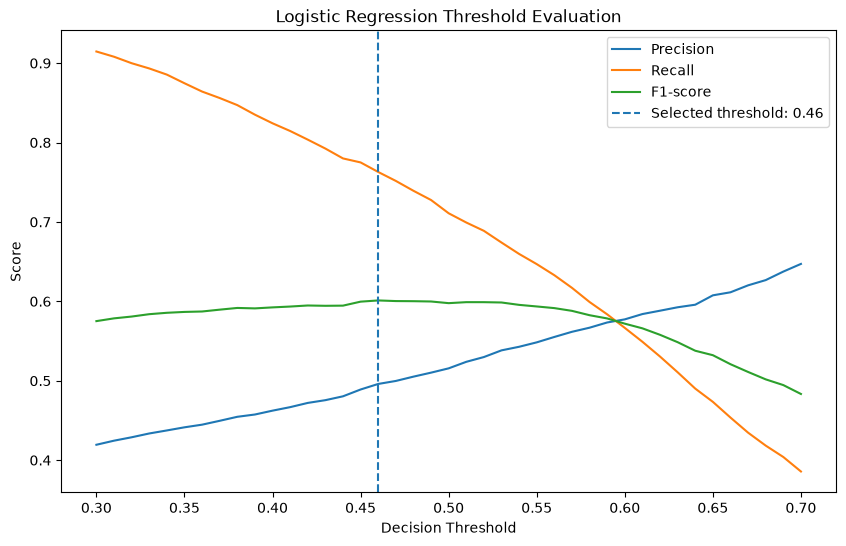

In [136]:
# Plot precision, recall and F1-score across the thresholds.

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precisionSpoiled"],
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recallSpoiled"],
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1Spoiled"],
    label="F1-score"
)

# Mark the selected threshold.

plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold: {selected_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title(
    "Logistic Regression Threshold Evaluation"
)
plt.legend()
plt.show()

In [137]:
# Refit the selected Logistic Regression pipeline
# using the complete training dataset.

logistic_pipeline.fit(
    X_train,
    y_train
)


# Generate spoilage probabilities for the test dataset.

final_test_probabilities = (
    logistic_pipeline.predict_proba(X_test)[:, 1]
)


# Apply the selected threshold instead of the default 0.50.

final_test_predictions = (
    final_test_probabilities >= selected_threshold
).astype(int)

In [138]:
# Calculate final test metrics using the selected threshold.

final_metrics = {
    "model": "Logistic Regression",
    "decisionThreshold": selected_threshold,
    "accuracy": accuracy_score(
        y_test,
        final_test_predictions
    ),
    "precisionSpoiled": precision_score(
        y_test,
        final_test_predictions,
        zero_division=0
    ),
    "recallSpoiled": recall_score(
        y_test,
        final_test_predictions
    ),
    "f1Spoiled": f1_score(
        y_test,
        final_test_predictions
    ),
    "rocAuc": roc_auc_score(
        y_test,
        final_test_probabilities
    )
}


final_metrics_df = pd.DataFrame(
    [final_metrics]
).round(3)

final_metrics_df

,model,decisionThreshold,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,rocAuc
0,Logistic Regression,0.46,0.66,0.482,0.759,0.59,0.769


In [139]:
# Create the confusion matrix for the tuned model.

final_confusion_matrix = confusion_matrix(
    y_test,
    final_test_predictions
)

final_confusion_matrix

array([[830, 526],
       [155, 489]])

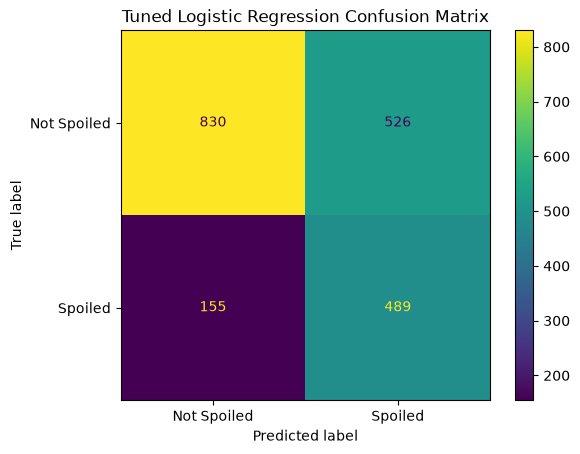

In [140]:
# Display the final confusion matrix.

ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=[
        "Not Spoiled",
        "Spoiled"
    ]
).plot()

plt.title(
    "Tuned Logistic Regression Confusion Matrix"
)

plt.show()

In [141]:
selected_threshold

0.46000000000000013

In [142]:
final_metrics_df

,model,decisionThreshold,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,rocAuc
0,Logistic Regression,0.46,0.66,0.482,0.759,0.59,0.769


In [143]:
final_confusion_matrix

array([[830, 526],
       [155, 489]])

In [144]:
# Convert the selected threshold to a regular Python float
# and remove the floating-point display artifact.

selected_threshold = round(
    float(selected_threshold),
    2
)

print("Final decision threshold:", selected_threshold)

Final decision threshold: 0.46


In [145]:
# Import the JSON library for saving model information.

import json


# Identify the data-science folder regardless of whether
# the notebook is running from the repository root or
# directly from the notebooks folder.

current_directory = Path.cwd()

if (current_directory / "data-science").exists():
    data_science_root = current_directory / "data-science"

elif (
    current_directory.name == "notebooks"
    and (current_directory.parent / "models").exists()
):
    data_science_root = current_directory.parent

else:
    raise FileNotFoundError(
        "The data-science folder could not be located."
    )


# Define the output folders.

models_directory = data_science_root / "models"
contracts_directory = data_science_root / "contracts"


# Create the folders if they do not already exist.

models_directory.mkdir(
    parents=True,
    exist_ok=True
)

contracts_directory.mkdir(
    parents=True,
    exist_ok=True
)


print("Models folder:", models_directory.resolve())
print("Contracts folder:", contracts_directory.resolve())

Models folder: C:\Users\Chimdinma\Documents\tECHY JAUNT\final project\generated_data\Farm2Market-GitHub\Tomatoes-Distribution-App\data-science\models
Contracts folder: C:\Users\Chimdinma\Documents\tECHY JAUNT\final project\generated_data\Farm2Market-GitHub\Tomatoes-Distribution-App\data-science\contracts


In [146]:
# Create a fresh copy of the selected Logistic Regression pipeline.
#
# This prevents the previously fitted model from being modified.

final_model_pipeline = clone(
    logistic_pipeline
)


# Train the deployment version using all available modelling records.
#
# The test results calculated earlier remain the official evaluation
# results. This full-data model is the version intended for deployment.

final_model_pipeline.fit(
    X,
    y
)

print("Final deployment model trained successfully.")

Final deployment model trained successfully.


In [147]:
# Define the final model filename.

model_path = (
    models_directory
    / "tomato_spoilage_model.pkl"
)


# Save the complete preprocessing and classification pipeline.

joblib.dump(
    final_model_pipeline,
    model_path
)


print("Model saved successfully.")
print("Model path:", model_path.resolve())

Model saved successfully.
Model path: C:\Users\Chimdinma\Documents\tECHY JAUNT\final project\generated_data\Farm2Market-GitHub\Tomatoes-Distribution-App\data-science\models\tomato_spoilage_model.pkl


In [148]:
# Collect the valid categorical values accepted by the model.
#
# These values should match the options used by the backend
# and frontend dropdown fields.

valid_categories = {
    column: sorted(
        model_df[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    for column in categorical_features
}


# Create a metadata document describing the model,
# threshold, features and evaluation results.

model_metadata = {
    "modelName": "Farm2Market Tomato Spoilage Risk Model",
    "modelVersion": "1.0.0",
    "algorithm": "Logistic Regression",
    "targetVariable": target,
    "classLabels": {
        "0": "notSpoiled",
        "1": "spoiled"
    },
    "decisionThreshold": selected_threshold,
    "modelFeatures": model_features,
    "categoricalFeatures": categorical_features,
    "numericalFeatures": numerical_features,
    "validCategories": valid_categories,
    "farmerFormFields": [
        "harvestDate",
        "harvestTime",
        "originState",
        "destinationMarket",
        "quantitySentCrates",
        "packagingType",
        "transportMode",
        "coldStorageAvailable",
        "storageType",
        "ripenessLevel",
        "initialDamageLevel"
    ],
    "backendDerivedFields": [
        "destinationCity",
        "season",
        "routeDistanceKm",
        "hoursSinceHarvestAtDispatch"
    ],
    "testMetrics": {
        "accuracy": round(
            float(final_metrics["accuracy"]),
            4
        ),
        "precisionSpoiled": round(
            float(final_metrics["precisionSpoiled"]),
            4
        ),
        "recallSpoiled": round(
            float(final_metrics["recallSpoiled"]),
            4
        ),
        "f1Spoiled": round(
            float(final_metrics["f1Spoiled"]),
            4
        ),
        "rocAuc": round(
            float(final_metrics["rocAuc"]),
            4
        )
    },
    "testConfusionMatrix": {
        "trueNegatives": int(
            final_confusion_matrix[0, 0]
        ),
        "falsePositives": int(
            final_confusion_matrix[0, 1]
        ),
        "falseNegatives": int(
            final_confusion_matrix[1, 0]
        ),
        "truePositives": int(
            final_confusion_matrix[1, 1]
        )
    },
    "dataNotice": (
        "The model was trained using synthetic data for prototype "
        "development. Its results are not field-validated performance "
        "estimates for Nigerian tomato shipments."
    )
}


# Define the metadata file path.

metadata_path = (
    models_directory
    / "tomato_spoilage_model_metadata.json"
)


# Save the metadata as readable JSON.

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        indent=4
    )


print("Model metadata saved successfully.")
print("Metadata path:", metadata_path.resolve())

Model metadata saved successfully.
Metadata path: C:\Users\Chimdinma\Documents\tECHY JAUNT\final project\generated_data\Farm2Market-GitHub\Tomatoes-Distribution-App\data-science\models\tomato_spoilage_model_metadata.json


In [149]:
# Collect the valid categorical values accepted by the model.
#
# These values should match the options used by the backend
# and frontend dropdown fields.

valid_categories = {
    column: sorted(
        model_df[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    for column in categorical_features
}


# Create a metadata document describing the model,
# threshold, features and evaluation results.

model_metadata = {
    "modelName": "Farm2Market Tomato Spoilage Risk Model",
    "modelVersion": "1.0.0",
    "algorithm": "Logistic Regression",
    "targetVariable": target,
    "classLabels": {
        "0": "notSpoiled",
        "1": "spoiled"
    },
    "decisionThreshold": selected_threshold,
    "modelFeatures": model_features,
    "categoricalFeatures": categorical_features,
    "numericalFeatures": numerical_features,
    "validCategories": valid_categories,
    "farmerFormFields": [
        "harvestDate",
        "harvestTime",
        "originState",
        "destinationMarket",
        "quantitySentCrates",
        "packagingType",
        "transportMode",
        "coldStorageAvailable",
        "storageType",
        "ripenessLevel",
        "initialDamageLevel"
    ],
    "backendDerivedFields": [
        "destinationCity",
        "season",
        "routeDistanceKm",
        "hoursSinceHarvestAtDispatch"
    ],
    "testMetrics": {
        "accuracy": round(
            float(final_metrics["accuracy"]),
            4
        ),
        "precisionSpoiled": round(
            float(final_metrics["precisionSpoiled"]),
            4
        ),
        "recallSpoiled": round(
            float(final_metrics["recallSpoiled"]),
            4
        ),
        "f1Spoiled": round(
            float(final_metrics["f1Spoiled"]),
            4
        ),
        "rocAuc": round(
            float(final_metrics["rocAuc"]),
            4
        )
    },
    "testConfusionMatrix": {
        "trueNegatives": int(
            final_confusion_matrix[0, 0]
        ),
        "falsePositives": int(
            final_confusion_matrix[0, 1]
        ),
        "falseNegatives": int(
            final_confusion_matrix[1, 0]
        ),
        "truePositives": int(
            final_confusion_matrix[1, 1]
        )
    },
    "dataNotice": (
        "The model was trained using synthetic data for prototype "
        "development. Its results are not field-validated performance "
        "estimates for Nigerian tomato shipments."
    )
}


# Define the metadata file path.

metadata_path = (
    models_directory
    / "tomato_spoilage_model_metadata.json"
)


# Save the metadata as readable JSON.

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        indent=4
    )


print("Model metadata saved successfully.")
print("Metadata path:", metadata_path.resolve())

Model metadata saved successfully.
Metadata path: C:\Users\Chimdinma\Documents\tECHY JAUNT\final project\generated_data\Farm2Market-GitHub\Tomatoes-Distribution-App\data-science\models\tomato_spoilage_model_metadata.json


In [150]:
# Create the contract used between:
#
# TypeScript backend -> Python FastAPI model service
#
# The frontend does not send this exact structure directly.
# The TypeScript backend first converts the farmer's form
# information into these model-ready values.

prediction_contract = {
    "endpoint": "/api/v1/predict-spoilage",
    "method": "POST",
    "modelVersion": "1.0.0",
    "requestExample": {
        "originState": valid_categories["originState"][0],
        "destinationCity": valid_categories["destinationCity"][0],
        "season": valid_categories["season"][0],
        "routeDistanceKm": 850.0,
        "quantitySentCrates": 120,
        "packagingType": valid_categories["packagingType"][0],
        "transportMode": valid_categories["transportMode"][0],
        "coldStorageAvailable": valid_categories[
            "coldStorageAvailable"
        ][0],
        "storageType": valid_categories["storageType"][0],
        "hoursSinceHarvestAtDispatch": 6.0,
        "ripenessLevel": valid_categories["ripenessLevel"][0],
        "initialDamageLevel": valid_categories[
            "initialDamageLevel"
        ][0]
    },
    "responseExample": {
        "spoilageProbability": 0.68,
        "predictedSpoilageStatus": 1,
        "riskLevel": "high",
        "recommendedAction": (
            "Prioritise dispatch and reduce storage delay."
        ),
        "decisionThreshold": selected_threshold,
        "modelVersion": "1.0.0"
    },
    "modelInputFields": model_features,
    "validCategories": valid_categories,
    "notes": {
        "destinationCity": (
            "Derived by the TypeScript backend from the destination "
            "market selected by the farmer."
        ),
        "season": (
            "Derived automatically from the harvest date."
        ),
        "routeDistanceKm": (
            "Obtained from the route lookup table using the selected "
            "origin and destination."
        ),
        "hoursSinceHarvestAtDispatch": (
            "Calculated from the harvest date and time and the "
            "dispatch or submission time."
        )
    }
}


# Save the corrected prediction contract.

contract_path = (
    contracts_directory
    / "backend_prediction_contract_camelcase.json"
)

with open(
    contract_path,
    "w",
    encoding="utf-8"
) as contract_file:
    json.dump(
        prediction_contract,
        contract_file,
        indent=4
    )


print("Prediction contract updated successfully.")
print("Contract path:", contract_path.resolve())

Prediction contract updated successfully.
Contract path: C:\Users\Chimdinma\Documents\tECHY JAUNT\final project\generated_data\Farm2Market-GitHub\Tomatoes-Distribution-App\data-science\contracts\backend_prediction_contract_camelcase.json


In [151]:
# Reload the saved model exactly as FastAPI will load it.

loaded_model = joblib.load(
    model_path
)


# Select one model-ready shipment record for a smoke test.

sample_shipment = X.iloc[[0]].copy()


# Generate the spoilage probability.

sample_probability = float(
    loaded_model.predict_proba(
        sample_shipment
    )[0, 1]
)


# Apply the selected 0.44 threshold.

sample_prediction = int(
    sample_probability >= selected_threshold
)


# Display the model input.

print("Sample model input:")
display(sample_shipment)


# Display the model output.

print(
    "Spoilage probability:",
    round(sample_probability, 4)
)

print(
    "Predicted spoilage status:",
    sample_prediction
)

print(
    "Decision threshold:",
    selected_threshold
)

Sample model input:


,originState,destinationCity,season,packagingType,transportMode,coldStorageAvailable,storageType,ripenessLevel,initialDamageLevel,routeDistanceKm,quantitySentCrates,hoursSinceHarvestAtDispatch
0,Kaduna,Ibadan,Dry Season,Plastic Crate,Covered Truck,Yes,Shaded Storage,Overripe,None,790.7,85,25.0


Spoilage probability: 0.2429
Predicted spoilage status: 0
Decision threshold: 0.46


In [152]:
# Confirm that all deployment files now exist.

deployment_files = [
    model_path,
    metadata_path,
    contract_path
]

for file_path in deployment_files:
    print(
        file_path.name,
        "->",
        file_path.exists()
    )

tomato_spoilage_model.pkl -> True
tomato_spoilage_model_metadata.json -> True
backend_prediction_contract_camelcase.json -> True


In [153]:
# Reload the saved model pipeline.
# This reproduces how the FastAPI service will load the model.

loaded_model = joblib.load(
    models_directory / "tomato_spoilage_model.pkl"
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [154]:
# Display every valid categorical value accepted by the model.
# These values should also be used by the frontend dropdowns.

for column in categorical_features:
    print(f"\n{column}:")
    print(sorted(model_df[column].astype(str).unique()))


originState:
['Gombe', 'Kaduna', 'Kano', 'Plateau']

destinationCity:
['Ibadan', 'Lagos', 'Onitsha', 'Port Harcourt']

season:
['Dry Season', 'Rainy Season']

packagingType:
['Plastic Crate', 'Raffia Basket', 'Sack', 'Wooden Crate']

transportMode:
['Covered Truck', 'Refrigerated Reefer Van', 'Traditional Open Truck']

coldStorageAvailable:
['No', 'Yes']

storageType:
['Cold Storage', 'No Storage', 'Open Storage', 'Shaded Storage']

ripenessLevel:
['Overripe', 'Ripe', 'Semi-ripe', 'Unripe']

initialDamageLevel:
['Low', 'Moderate', 'None', 'Severe']


In [155]:
# Display the categorical features currently stored in memory.

categorical_features

['originState',
 'destinationCity',
 'season',
 'packagingType',
 'transportMode',
 'coldStorageAvailable',
 'storageType',
 'ripenessLevel',
 'initialDamageLevel']

In [156]:
# Display the valid categorical values accepted by the model.
#
# astype("string") converts mixed values into pandas text values.
# dropna() removes genuine missing values before sorting.
# str.strip() removes accidental spaces around category names.

for column in categorical_features:
    clean_values = (
        model_df[column]
        .astype("string")
        .dropna()
        .str.strip()
        .unique()
        .tolist()
    )

    # Sort the cleaned text values alphabetically.
    clean_values = sorted(clean_values)

    print(f"\n{column}:")
    print(clean_values)

    # Also report missing values so they are not hidden.
    print(
        "Missing values:",
        model_df[column].isna().sum()
    )


originState:
['Gombe', 'Kaduna', 'Kano', 'Plateau']
Missing values: 0

destinationCity:
['Ibadan', 'Lagos', 'Onitsha', 'Port Harcourt']
Missing values: 0

season:
['Dry Season', 'Rainy Season']
Missing values: 0

packagingType:
['Plastic Crate', 'Raffia Basket', 'Sack', 'Wooden Crate']
Missing values: 0

transportMode:
['Covered Truck', 'Refrigerated Reefer Van', 'Traditional Open Truck']
Missing values: 0

coldStorageAvailable:
['No', 'Yes']
Missing values: 0

storageType:
['Cold Storage', 'No Storage', 'Open Storage', 'Shaded Storage']
Missing values: 0

ripenessLevel:
['Overripe', 'Ripe', 'Semi-ripe', 'Unripe']
Missing values: 0

initialDamageLevel:
['Low', 'Moderate', 'None', 'Severe']
Missing values: 0


In [157]:
# Inspect the Python data types present inside each categorical column.

for column in categorical_features:
    value_types = (
        model_df[column]
        .map(type)
        .value_counts()
    )

    print(f"\n{column}:")
    print(value_types)


originState:
originState
<class 'str'>    10000
Name: count, dtype: int64

destinationCity:
destinationCity
<class 'str'>    10000
Name: count, dtype: int64

season:
season
<class 'str'>    10000
Name: count, dtype: int64

packagingType:
packagingType
<class 'str'>    10000
Name: count, dtype: int64

transportMode:
transportMode
<class 'str'>    10000
Name: count, dtype: int64

coldStorageAvailable:
coldStorageAvailable
<class 'str'>    10000
Name: count, dtype: int64

storageType:
storageType
<class 'str'>    10000
Name: count, dtype: int64

ripenessLevel:
ripenessLevel
<class 'str'>    10000
Name: count, dtype: int64

initialDamageLevel:
initialDamageLevel
<class 'str'>    10000
Name: count, dtype: int64


In [158]:
# Confirm that "None" is now preserved as a real category.

df["initialDamageLevel"].value_counts(dropna=False)

initialDamageLevel
Low         3441
Moderate    2844
None        2506
Severe      1209
Name: count, dtype: int64

In [159]:
# Every value should now be stored as text.

df["initialDamageLevel"].map(type).value_counts()

initialDamageLevel
<class 'str'>    10000
Name: count, dtype: int64

In [160]:
# Confirm that no selected categorical feature contains missing values.

df[categorical_features].isna().sum()

originState             0
destinationCity         0
season                  0
packagingType           0
transportMode           0
coldStorageAvailable    0
storageType             0
ripenessLevel           0
initialDamageLevel      0
dtype: int64

In [161]:
# Confirm that "None" is now treated as a genuine damage category
# rather than as a missing value.

print("Initial damage categories:")
print(df["initialDamageLevel"].value_counts(dropna=False))


# Confirm that all initialDamageLevel values are stored as text.

print("\nPython value types:")
print(df["initialDamageLevel"].map(type).value_counts())


# Confirm that the final modelling dataset has no missing values.

print(
    "\nTotal missing values in model_df:",
    model_df.isna().sum().sum()
)


# Confirm the final model feature list.

print("\nModel features:")
print(model_features)


# Display the newly calculated model results.

print("\nModel comparison:")
display(model_comparison)


print("\nSelected threshold:")
print(round(float(selected_threshold), 2))


print("\nFinal tuned model metrics:")
display(final_metrics_df)


print("\nFinal confusion matrix:")
print(final_confusion_matrix)

Initial damage categories:
initialDamageLevel
Low         3441
Moderate    2844
None        2506
Severe      1209
Name: count, dtype: int64

Python value types:
initialDamageLevel
<class 'str'>    10000
Name: count, dtype: int64

Total missing values in model_df: 0

Model features:
['originState', 'destinationCity', 'season', 'packagingType', 'transportMode', 'coldStorageAvailable', 'storageType', 'ripenessLevel', 'initialDamageLevel', 'routeDistanceKm', 'quantitySentCrates', 'hoursSinceHarvestAtDispatch']

Model comparison:


,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,rocAuc
model,,,,,
Logistic Regression,0.686,0.508,0.711,0.593,0.769
Random Forest,0.696,0.525,0.579,0.551,0.747



Selected threshold:
0.46

Final tuned model metrics:


,model,decisionThreshold,accuracy,precisionSpoiled,recallSpoiled,f1Spoiled,rocAuc
0,Logistic Regression,0.46,0.66,0.482,0.759,0.59,0.769



Final confusion matrix:
[[830 526]
 [155 489]]


In [162]:
# Verify that the corrected deployment files exist.

deployment_files = [
    model_path,
    metadata_path,
    contract_path
]

for file_path in deployment_files:
    print(
        file_path.name,
        "exists:",
        file_path.exists()
    )

tomato_spoilage_model.pkl exists: True
tomato_spoilage_model_metadata.json exists: True
backend_prediction_contract_camelcase.json exists: True


In [163]:
# Generate spoilage probabilities for the unseen test data.
#
# logistic_pipeline was trained using X_train only,
# so X_test remains suitable for evaluating performance.

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, 1]


# Convert the probabilities into class predictions
# using the selected decision threshold.

test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)


print("Number of test records:", len(test_predictions))
print("Decision threshold:", selected_threshold)

Number of test records: 2000
Decision threshold: 0.46


In [164]:
# Create a copy of the original test input data.

test_results = X_test.reset_index(drop=True).copy()


# Add the known correct result from y_test.

test_results["actualStatus"] = (
    y_test.reset_index(drop=True)
)


# Add the model prediction.

test_results["predictedStatus"] = (
    test_predictions
)


# Add the predicted spoilage probability.

test_results["spoilageProbability"] = (
    test_probabilities
)


# Convert probability into percentage for easier reading.

test_results["spoilagePercentage"] = (
    test_results["spoilageProbability"] * 100
).round(2)


# Show whether each prediction was correct.

test_results["predictionCorrect"] = (
    test_results["actualStatus"]
    == test_results["predictedStatus"]
)


test_results.head(10)

,originState,destinationCity,season,packagingType,transportMode,coldStorageAvailable,storageType,ripenessLevel,initialDamageLevel,routeDistanceKm,quantitySentCrates,hoursSinceHarvestAtDispatch,actualStatus,predictedStatus,spoilageProbability,spoilagePercentage,predictionCorrect
0,Plateau,Ibadan,Rainy Season,Sack,Covered Truck,No,Open Storage,Ripe,Moderate,825.9,230,5.9,0,1,0.591977,59.20,False
1,Kano,Port Harcourt,Rainy Season,Raffia Basket,Traditional Open Truck,No,Open Storage,Ripe,Moderate,1245.2,290,3.1,0,1,0.789158,78.92,False
2,Kano,Port Harcourt,Rainy Season,Plastic Crate,Traditional Open Truck,No,Open Storage,Ripe,Moderate,1251.2,172,23.4,1,1,0.745597,74.56,True
3,Gombe,Port Harcourt,Dry Season,Plastic Crate,Covered Truck,No,No Storage,Ripe,None,984.1,129,18.0,1,0,0.318513,31.85,False
4,Kano,Ibadan,Rainy Season,Plastic Crate,Traditional Open Truck,Yes,Open Storage,Overripe,Low,1065.7,129,7.2,1,1,0.518686,51.87,True
5,Kaduna,Port Harcourt,Rainy Season,Raffia Basket,Covered Truck,No,Open Storage,Ripe,None,1060.8,208,35.7,1,1,0.624811,62.48,True
6,Plateau,Port Harcourt,Rainy Season,Raffia Basket,Covered Truck,No,Open Storage,Unripe,None,743.7,283,21.8,0,0,0.230589,23.06,True
7,Plateau,Onitsha,Dry Season,Raffia Basket,Traditional Open Truck,No,No Storage,Semi-ripe,Moderate,567.7,206,22.1,0,1,0.750269,75.03,False
8,Kaduna,Lagos,Rainy Season,Plastic Crate,Traditional Open Truck,No,Open Storage,Unripe,Low,867.4,162,19.8,0,0,0.293728,29.37,True
9,Kaduna,Onitsha,Rainy Season,Wooden Crate,Covered Truck,No,Shaded Storage,Ripe,Low,800.3,250,7.6,0,0,0.258336,25.83,True


In [165]:
# Convert numeric classes into readable labels.

status_labels = {
    0: "Not Spoiled",
    1: "Spoiled"
}


test_results["actualLabel"] = (
    test_results["actualStatus"]
    .map(status_labels)
)


test_results["predictedLabel"] = (
    test_results["predictedStatus"]
    .map(status_labels)
)


test_results[
    [
        "originState",
        "destinationCity",
        "packagingType",
        "transportMode",
        "actualLabel",
        "predictedLabel",
        "spoilagePercentage",
        "predictionCorrect"
    ]
].head(10)

,originState,destinationCity,packagingType,transportMode,actualLabel,predictedLabel,spoilagePercentage,predictionCorrect
0,Plateau,Ibadan,Sack,Covered Truck,Not Spoiled,Spoiled,59.20,False
1,Kano,Port Harcourt,Raffia Basket,Traditional Open Truck,Not Spoiled,Spoiled,78.92,False
2,Kano,Port Harcourt,Plastic Crate,Traditional Open Truck,Spoiled,Spoiled,74.56,True
3,Gombe,Port Harcourt,Plastic Crate,Covered Truck,Spoiled,Not Spoiled,31.85,False
4,Kano,Ibadan,Plastic Crate,Traditional Open Truck,Spoiled,Spoiled,51.87,True
5,Kaduna,Port Harcourt,Raffia Basket,Covered Truck,Spoiled,Spoiled,62.48,True
6,Plateau,Port Harcourt,Raffia Basket,Covered Truck,Not Spoiled,Not Spoiled,23.06,True
7,Plateau,Onitsha,Raffia Basket,Traditional Open Truck,Not Spoiled,Spoiled,75.03,False
8,Kaduna,Lagos,Plastic Crate,Traditional Open Truck,Not Spoiled,Not Spoiled,29.37,True
9,Kaduna,Onitsha,Wooden Crate,Covered Truck,Not Spoiled,Not Spoiled,25.83,True


In [166]:
# Calculate performance on the unseen test data.

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions
)

test_f1 = f1_score(
    y_test,
    test_predictions
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)


test_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision for Spoiled",
        "Recall for Spoiled",
        "F1-score for Spoiled",
        "ROC-AUC"
    ],
    "score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})


test_metrics["score"] = (
    test_metrics["score"].round(3)
)


test_metrics

,metric,score
0,Accuracy,0.660
1,Precision for Spoiled,0.482
2,Recall for Spoiled,0.759
3,F1-score for Spoiled,0.590
4,ROC-AUC,0.769


In [167]:
# Find actual spoiled shipments that the model predicted
# as not spoiled.

false_negatives = test_results[
    (test_results["actualStatus"] == 1)
    & (test_results["predictedStatus"] == 0)
].copy()


print("Number of false negatives:", len(false_negatives))


false_negatives[
    [
        "originState",
        "destinationCity",
        "packagingType",
        "transportMode",
        "coldStorageAvailable",
        "storageType",
        "ripenessLevel",
        "initialDamageLevel",
        "spoilagePercentage"
    ]
].head(10)

Number of false negatives: 155


,originState,destinationCity,packagingType,transportMode,coldStorageAvailable,storageType,ripenessLevel,initialDamageLevel,spoilagePercentage
3,Gombe,Port Harcourt,Plastic Crate,Covered Truck,No,No Storage,Ripe,None,31.85
24,Gombe,Ibadan,Sack,Covered Truck,Yes,Cold Storage,Unripe,Low,21.07
38,Gombe,Ibadan,Plastic Crate,Covered Truck,No,Open Storage,Semi-ripe,Low,33.92
47,Kano,Onitsha,Plastic Crate,Covered Truck,No,Open Storage,Overripe,None,33.57
83,Kano,Lagos,Wooden Crate,Refrigerated Reefer Van,Yes,No Storage,Ripe,Moderate,37.04
91,Gombe,Onitsha,Wooden Crate,Covered Truck,No,No Storage,Unripe,Moderate,37.93
105,Plateau,Onitsha,Raffia Basket,Covered Truck,No,Open Storage,Unripe,None,24.33
121,Kaduna,Port Harcourt,Plastic Crate,Covered Truck,No,Shaded Storage,Ripe,Moderate,37.42
176,Plateau,Lagos,Plastic Crate,Traditional Open Truck,No,No Storage,Unripe,Low,21.79
184,Kano,Port Harcourt,Plastic Crate,Covered Truck,No,Open Storage,Semi-ripe,None,24.35


In [168]:
# Find actual non-spoiled shipments that the model
# predicted as spoiled.

false_positives = test_results[
    (test_results["actualStatus"] == 0)
    & (test_results["predictedStatus"] == 1)
].copy()


print("Number of false positives:", len(false_positives))


false_positives[
    [
        "originState",
        "destinationCity",
        "packagingType",
        "transportMode",
        "coldStorageAvailable",
        "storageType",
        "ripenessLevel",
        "initialDamageLevel",
        "spoilagePercentage"
    ]
].head(10)

Number of false positives: 526


,originState,destinationCity,packagingType,transportMode,coldStorageAvailable,storageType,ripenessLevel,initialDamageLevel,spoilagePercentage
0,Plateau,Ibadan,Sack,Covered Truck,No,Open Storage,Ripe,Moderate,59.20
1,Kano,Port Harcourt,Raffia Basket,Traditional Open Truck,No,Open Storage,Ripe,Moderate,78.92
7,Plateau,Onitsha,Raffia Basket,Traditional Open Truck,No,No Storage,Semi-ripe,Moderate,75.03
11,Kano,Port Harcourt,Raffia Basket,Covered Truck,No,Open Storage,Ripe,Low,66.98
12,Kaduna,Port Harcourt,Raffia Basket,Traditional Open Truck,No,Open Storage,Semi-ripe,Low,50.62
18,Kaduna,Lagos,Raffia Basket,Covered Truck,No,Open Storage,Ripe,Low,46.58
19,Gombe,Ibadan,Plastic Crate,Traditional Open Truck,No,Open Storage,Ripe,Low,54.66
27,Kano,Lagos,Raffia Basket,Covered Truck,No,Open Storage,Ripe,Moderate,62.92
29,Gombe,Lagos,Plastic Crate,Traditional Open Truck,No,Open Storage,Ripe,Low,52.34
33,Plateau,Lagos,Sack,Covered Truck,No,No Storage,Ripe,Moderate,65.04


In [169]:
# Select five shipment records to test the saved deployment model.
#
# This is a functionality test, not an unbiased performance test,
# because the deployment model was retrained using all available data.

deployment_test_data = (
    X_test
    .head(5)
    .copy()
)


deployment_probabilities = (
    loaded_model.predict_proba(
        deployment_test_data
    )[:, 1]
)


deployment_predictions = (
    deployment_probabilities >= selected_threshold
).astype(int)


deployment_test_results = (
    deployment_test_data
    .reset_index(drop=True)
    .copy()
)


deployment_test_results["spoilageProbability"] = (
    deployment_probabilities.round(4)
)


deployment_test_results["spoilagePercentage"] = (
    deployment_probabilities * 100
).round(2)


deployment_test_results["predictedStatus"] = (
    deployment_predictions
)


deployment_test_results["predictedLabel"] = (
    deployment_test_results["predictedStatus"]
    .map(status_labels)
)


deployment_test_results

,originState,destinationCity,season,packagingType,transportMode,coldStorageAvailable,storageType,ripenessLevel,initialDamageLevel,routeDistanceKm,quantitySentCrates,hoursSinceHarvestAtDispatch,spoilageProbability,spoilagePercentage,predictedStatus,predictedLabel
0,Plateau,Ibadan,Rainy Season,Sack,Covered Truck,No,Open Storage,Ripe,Moderate,825.9,230,5.9,0.5742,57.42,1,Spoiled
1,Kano,Port Harcourt,Rainy Season,Raffia Basket,Traditional Open Truck,No,Open Storage,Ripe,Moderate,1245.2,290,3.1,0.7730,77.30,1,Spoiled
2,Kano,Port Harcourt,Rainy Season,Plastic Crate,Traditional Open Truck,No,Open Storage,Ripe,Moderate,1251.2,172,23.4,0.7429,74.29,1,Spoiled
3,Gombe,Port Harcourt,Dry Season,Plastic Crate,Covered Truck,No,No Storage,Ripe,None,984.1,129,18.0,0.3081,30.81,0,Not Spoiled
4,Kano,Ibadan,Rainy Season,Plastic Crate,Traditional Open Truck,Yes,Open Storage,Overripe,Low,1065.7,129,7.2,0.5380,53.80,1,Spoiled


In [170]:
# Display the exact categorical values used during model training.
# The frontend dropdown options must use these same values.

for column in categorical_features:
    valid_values = sorted(
        model_df[column]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    print(f"\n{column}:")
    print(valid_values)


originState:
['Gombe', 'Kaduna', 'Kano', 'Plateau']

destinationCity:
['Ibadan', 'Lagos', 'Onitsha', 'Port Harcourt']

season:
['Dry Season', 'Rainy Season']

packagingType:
['Plastic Crate', 'Raffia Basket', 'Sack', 'Wooden Crate']

transportMode:
['Covered Truck', 'Refrigerated Reefer Van', 'Traditional Open Truck']

coldStorageAvailable:
['No', 'Yes']

storageType:
['Cold Storage', 'No Storage', 'Open Storage', 'Shaded Storage']

ripenessLevel:
['Overripe', 'Ripe', 'Semi-ripe', 'Unripe']

initialDamageLevel:
['Low', 'Moderate', 'None', 'Severe']


In [171]:
# Map the farmer-facing destination market to the city
# expected by the trained model.

destination_market_to_city = {
    "Mile 12 Market, Lagos": "Lagos",
    "Bodija Market, Ibadan": "Ibadan",
    "Oil Mill Market, Port Harcourt": "Port Harcourt",
    "Onitsha Market": "Onitsha"
}


# Build a route-distance lookup from the actual training dataset.
# The median distance is used for each origin-destination combination.

route_distance_lookup = (
    df.groupby(
        ["originState", "destinationCity"]
    )["routeDistanceKm"]
    .median()
    .to_dict()
)


# Derive the season from the same month-to-season relationship
# used in the training dataset.

month_to_season = (
    df.assign(
        shipmentMonth=pd.to_datetime(
            df["shipmentDate"]
        ).dt.month
    )
    .groupby("shipmentMonth")["season"]
    .agg(lambda values: values.mode().iloc[0])
    .to_dict()
)


print("Backend lookup tables created successfully.")

Backend lookup tables created successfully.


In [172]:
def predict_from_farmer_form(
    harvest_date,
    harvest_time,
    dispatch_datetime,
    origin_state,
    destination_market,
    quantity_sent_crates,
    packaging_type,
    transport_mode,
    cold_storage_available,
    storage_type,
    ripeness_level,
    initial_damage_level,
    model,
    threshold
):
    """
    Simulate the complete prediction process used by the application.

    The function accepts the information entered by the farmer,
    calculates the backend-derived fields, runs the saved model
    and returns a farmer-friendly result.
    """

    # Combine the harvest date and time into one timestamp.
    harvest_datetime = pd.Timestamp(
        f"{harvest_date} {harvest_time}"
    )

    # Convert the proposed dispatch time into a timestamp.
    dispatch_datetime = pd.Timestamp(
        dispatch_datetime
    )

    # The dispatch time must not occur before harvest.
    if dispatch_datetime < harvest_datetime:
        raise ValueError(
            "Dispatch time cannot occur before harvest time."
        )

    # Calculate the number of hours between harvest and dispatch.
    hours_since_harvest = (
        dispatch_datetime - harvest_datetime
    ).total_seconds() / 3600

    # Convert the selected market into the city used by the model.
    if destination_market not in destination_market_to_city:
        raise ValueError(
            f"Unknown destination market: {destination_market}"
        )

    destination_city = destination_market_to_city[
        destination_market
    ]

    # Derive the season from the harvest month.
    season = month_to_season[
        harvest_datetime.month
    ]

    # Obtain the route distance from the dataset lookup table.
    route_key = (
        origin_state,
        destination_city
    )

    if route_key not in route_distance_lookup:
        raise ValueError(
            "No route distance exists for the selected "
            "origin and destination."
        )

    route_distance_km = route_distance_lookup[
        route_key
    ]

    # Create the exact model input structure.
    model_input = pd.DataFrame([
        {
            "originState": origin_state,
            "destinationCity": destination_city,
            "season": season,
            "routeDistanceKm": route_distance_km,
            "quantitySentCrates": quantity_sent_crates,
            "packagingType": packaging_type,
            "transportMode": transport_mode,
            "coldStorageAvailable": cold_storage_available,
            "storageType": storage_type,
            "hoursSinceHarvestAtDispatch": hours_since_harvest,
            "ripenessLevel": ripeness_level,
            "initialDamageLevel": initial_damage_level
        }
    ])

    # Arrange the columns in the same order used during training.
    model_input = model_input[model_features]

    # Generate the probability of spoilage.
    spoilage_probability = float(
        model.predict_proba(model_input)[0, 1]
    )

    # Apply the selected model threshold.
    predicted_status = int(
        spoilage_probability >= threshold
    )

    # Convert the probability into a farmer-friendly risk result.
    if spoilage_probability >= threshold:
        risk_level = "High"
        prediction_label = "High spoilage risk"
        recommendation = (
            "Prioritise immediate dispatch and reduce further "
            "storage time. Use cold storage or protected "
            "transport where available."
        )

    elif spoilage_probability >= 0.30:
        risk_level = "Moderate"
        prediction_label = "Moderate spoilage risk"
        recommendation = (
            "Dispatch promptly and maintain careful packaging, "
            "storage and handling."
        )

    else:
        risk_level = "Low"
        prediction_label = "Lower spoilage risk"
        recommendation = (
            "Proceed with the planned dispatch while maintaining "
            "proper handling and protection from heat."
        )

    # Return the same type of result that FastAPI will later send.
    result = {
        "spoilageProbability": round(
            spoilage_probability,
            4
        ),
        "spoilagePercentage": round(
            spoilage_probability * 100,
            2
        ),
        "predictedSpoilageStatus": predicted_status,
        "predictionLabel": prediction_label,
        "riskLevel": risk_level,
        "recommendedAction": recommendation,
        "decisionThreshold": round(
            float(threshold),
            2
        ),
        "derivedFields": {
            "destinationCity": destination_city,
            "season": season,
            "routeDistanceKm": round(
                float(route_distance_km),
                2
            ),
            "hoursSinceHarvestAtDispatch": round(
                hours_since_harvest,
                2
            )
        }
    }

    return model_input, result

In [173]:
# Test a shipment exactly as though a farmer completed the form.

shipment_input, shipment_result = predict_from_farmer_form(
    harvest_date="2026-07-18",
    harvest_time="06:00",
    dispatch_datetime="2026-07-18 16:00",
    origin_state="Kano",
    destination_market="Mile 12 Market, Lagos",
    quantity_sent_crates=150,
    packaging_type="Plastic Crate",
    transport_mode="Covered Truck",
    cold_storage_available="No",
    storage_type="Open Storage",
    ripeness_level="Ripe",
    initial_damage_level="Moderate",
    model=loaded_model,
    threshold=selected_threshold
)

In [174]:
shipment_input

,originState,destinationCity,season,packagingType,transportMode,coldStorageAvailable,storageType,ripenessLevel,initialDamageLevel,routeDistanceKm,quantitySentCrates,hoursSinceHarvestAtDispatch
0,Kano,Lagos,Rainy Season,Plastic Crate,Covered Truck,No,Open Storage,Ripe,Moderate,1155.7,150,10.0


In [175]:
shipment_result

{'spoilageProbability': 0.4327,
 'spoilagePercentage': 43.27,
 'predictedSpoilageStatus': 0,
 'predictionLabel': 'Moderate spoilage risk',
 'riskLevel': 'Moderate',
 'recommendedAction': 'Dispatch promptly and maintain careful packaging, storage and handling.',
 'decisionThreshold': 0.46,
 'derivedFields': {'destinationCity': 'Lagos',
  'season': 'Rainy Season',
  'routeDistanceKm': 1155.7,
  'hoursSinceHarvestAtDispatch': 10.0}}

In [176]:
# Confirm that the final model, metadata and prediction contract
# exist after retraining with the corrected dataset.

final_model_path = (
    data_science_root
    / "models"
    / "tomato_spoilage_model.pkl"
)

final_metadata_path = (
    data_science_root
    / "models"
    / "tomato_spoilage_model_metadata.json"
)

final_contract_path = (
    data_science_root
    / "contracts"
    / "backend_prediction_contract_camelcase.json"
)


deployment_files = [
    final_model_path,
    final_metadata_path,
    final_contract_path
]


for file_path in deployment_files:
    print(
        file_path.name,
        "exists:",
        file_path.exists()
    )

tomato_spoilage_model.pkl exists: True
tomato_spoilage_model_metadata.json exists: True
backend_prediction_contract_camelcase.json exists: True


In [177]:
# Create a results folder for functional test outputs.

results_directory = (
    data_science_root
    / "results"
)

results_directory.mkdir(
    parents=True,
    exist_ok=True
)


# Save the manual shipment input and the model output together.

manual_test_record = {
    "testName": "Manual farmer-form prediction test",
    "modelVersion": "1.0.0",
    "decisionThreshold": round(
        float(selected_threshold),
        2
    ),
    "modelInput": shipment_input.iloc[0].to_dict(),
    "predictionOutput": shipment_result
}


manual_test_path = (
    results_directory
    / "manual_prediction_test.json"
)


with open(
    manual_test_path,
    "w",
    encoding="utf-8"
) as test_file:
    json.dump(
        manual_test_record,
        test_file,
        indent=4
    )


print("Manual test saved to:")
print(manual_test_path.resolve())

Manual test saved to:
C:\Users\Chimdinma\Documents\tECHY JAUNT\final project\generated_data\Farm2Market-GitHub\Tomatoes-Distribution-App\data-science\results\manual_prediction_test.json
